# Predict the age of abalone from categorical and continuous data using deep learning

Your goal is to design and implement a custom dataset class, neural network architecture, and training loop to predict the age of abalone. Abalone is a type of sea snail with a flat, round shell. The age of an abalone is determined by cutting its shell through the cone, staining it, and counting the number of rings under a microscope—a tedious and time-consuming task. Other physical measurements, which are easier to obtain, can serve as proxies for predicting age in a high-throughput manner.

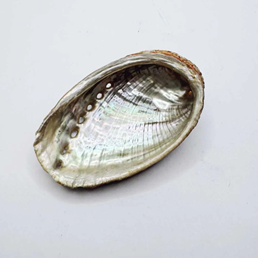

You have to preprocess the dataset, apply appropriate splits, and develop a neural network architecture, such that your neural network can predict the abalone’s age on the test data.

# Dataset
The abalone dataset is already prepared for you and can be found on Canvas: train.csv and test.csv. Both datasets contain 8 input variables, and 1 target variable (which needs to be predicted by your deep learning model): the number of rings (which corresponds to the age). The datasets are structured as follows:

| Variable Name    | Role                     | Data Type    | Description                         | Range              |
|:-----------------|:-------------------------|:-------------|:------------------------------------|:-------------------|
| Sex              | Input variable           | Categorical  | M (male), F (female), I (infant)    | –                  |
| Length           | Input variable           | Continuous   | Longest shell measurement           | 0.075 – 0.815      |
| Diameter         | Input variable           | Continuous   | Perpendicular to the length         | 0.055 – 0.65       |
| Height           | Input variable           | Continuous   | With meat in shell                  | 0 – 1.13           |
| Whole_weight     | Input variable           | Continuous   | Whole abalone                       | 0.002 – 2.8255     |
| Shucked_weight   | Input variable           | Continuous   | Weight of meat                      | 0.001 – 1.488      |
| Viscera_weight   | Input variable           | Continuous   | Gut weight                          | 0.0005 – 0.76      |
| Shell_weight     | Input variable           | Continuous   | After being dried                   | 0.0015 – 1.005     |
| Rings            | Target variable (output) | Integer      | Indication for the age              | 1 – 29             |

# Import libraries

In [9]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import platform
import pandas as pd
import numpy as np
from pickle import load, dump
from numpy import arange
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score, root_mean_squared_log_error
import matplotlib.pyplot as plt

# Set seed for reproducibility

In [10]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # For GPU
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ToDo: implement custom dataset class
Here, you have to implement a custom PyTorch `Dataset` for the Abalone data.  
Your dataset should prepare the raw CSV data so it can be used directly by a neural network.

Think carefully about:

- How to separate inputs and targets  
- How to handle categorical variables  
- How to treat continuous features  
- When and how to compute normalization statistics  

---

## Things to keep in mind

- Avoid data leakage between train and validation sets.
- Ensure consistent preprocessing across splits.
- Verify tensor shapes before training.

In [11]:
from sklearn.model_selection import train_test_split

class AbaloneDataset(Dataset):
    def __init__(self, df, target_column, gender_mapping, continuous_features, mean=None, std=None, fit_stats=False):

        self.gender_mapping = gender_mapping
        self.continuous_features = continuous_features

        targets = df[target_column]
        features = df.drop(columns=[target_column])

        gender_labels = features['Sex'].map(gender_mapping).values
        gender_one_hot = torch.nn.functional.one_hot(torch.tensor(gender_labels), num_classes=3).numpy()

        continuous_data = features[continuous_features].values

        if fit_stats:
            self.mean = continuous_data.mean(axis=0)
            self.std = continuous_data.std(axis=0)
        else:
            self.mean = mean
            self.std = std

        continuous_data = (continuous_data - self.mean) / self.std

        self.features = torch.tensor(np.hstack((gender_one_hot, continuous_data)), dtype=torch.float32)
        self.targets = torch.tensor(targets.values, dtype=torch.float32).unsqueeze(1)


    def __len__(self):
        return len(self.features)


    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

# ToDo: implement neural network 
Here, you have to implement a simple feedforward network to predict properties of the Abalone dataset.

Key points to consider:

- The network takes preprocessed features as input and produces a single output per sample.  
- Use appropriate activation functions in hidden layers.  
- Think carefully about how the network should predict the target.

In [12]:
class AbaloneRegressionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, output_dim):
        super().__init__()
        
        self.fc = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(hidden_dim2, output_dim),
        )
    
    def forward(self, x):
        return self.fc(x)

# Function to train model

In [13]:
def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=100, device='cpu'):
    model.to(device)
    best_val_loss = float('inf')

    writer = SummaryWriter(log_dir='runs/abalone_training')

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)

        print(f"Epoch {epoch + 1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        # Save the best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_model.pth")
            print("Saved Best Model")

        writer.add_scalars('loss', {'train': train_loss, 'val': val_loss}, epoch)

    writer.close()

# Function to evaluate model

In [14]:
def evaluate_model(model, test_loader, device, criterion):
    model.to(device)
    model.eval()
    test_loss = 0.0
    predictions = []

    with torch.no_grad():
        for batch in test_loader:
            inputs, targets = batch
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            loss = criterion(outputs, targets)
            test_loss += loss.item()
            
            predictions.extend(outputs.cpu().numpy())

    test_loss /= len(test_loader)
    print(f"Test Loss: {test_loss:.4f}")
    
    return test_loss, np.concatenate(predictions)

# Function to calculate metrics

In [15]:
def calculate_metrics(targets, predictions):
    mae = mean_absolute_error(targets, predictions)
    mse = mean_squared_error(targets, predictions)
    rmse = root_mean_squared_error(targets, predictions)
    rmsle = root_mean_squared_log_error(targets, np.maximum(predictions, 0))
    r2 = r2_score(targets.numpy(), predictions)

    metrics = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "RMSLE": rmsle,
        "R2": r2,
    }
    return metrics

# Function to plot the predictions

In [16]:
def plot_predictions(targets, predictions, r2):
    plt.scatter(targets, predictions, color='blue', label='Predictions', alpha=0.7)
    plt.plot([min(targets), max(targets)], [min(targets), max(targets)], 
             color='red', linestyle='--', label='y = x')

    plt.xlabel("Real Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Predictions vs Real Values\n$R^2$ = {r2:.2f}")
    plt.legend()

    plt.grid(True)

# ToDo: implement the full training pipeline for the Abalone dataset

Key points to reflect on:

- Selecting the appropriate device for computation.  
- Organizing data into training, validation, and test splits.  
- Preparing datasets and loaders to efficiently feed the model.  
- Choosing how the model, loss function, and optimizer interact.  
- Structuring the training loop and deciding how long to train.  

---

## Things to keep in mind

- Data preprocessing should be consistent across all splits.  
- Batch size, learning rate, and regularization can significantly affect results.  
- Consider how the model and training choices influence generalization.  

In [17]:
if platform.system() == "Darwin":
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_csv = "./Data/train.csv"
test_csv = "./Data/test.csv"
target_column = "Rings"
gender_mapping = {'M': 0, 'F': 1, 'I': 2}
continuous_features = ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight']
epochs = 100

# Create Datasets
train_df = pd.read_csv(train_csv)
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)
test_df  = pd.read_csv(test_csv)

train_dataset = AbaloneDataset(train_df, target_column, gender_mapping, continuous_features, fit_stats=True)
val_dataset = AbaloneDataset(val_df, target_column, gender_mapping, continuous_features, mean=train_dataset.mean, std=train_dataset.std)
test_dataset = AbaloneDataset(test_df, target_column, gender_mapping, continuous_features, mean=train_dataset.mean, std=train_dataset.std)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

model = AbaloneRegressionModel(input_dim=train_dataset.features.shape[1],
                               hidden_dim1=32,
                               hidden_dim2=16,
                               output_dim=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)

train_model(model, criterion, optimizer, train_loader, val_loader, epochs, device)

Using device: cpu
Epoch 1/100, Train Loss: 38.3163, Val Loss: 5.8800
Saved Best Model
Epoch 2/100, Train Loss: 6.1403, Val Loss: 4.4047
Saved Best Model
Epoch 3/100, Train Loss: 5.2629, Val Loss: 4.1390
Saved Best Model
Epoch 4/100, Train Loss: 4.9863, Val Loss: 4.6065
Epoch 5/100, Train Loss: 5.0186, Val Loss: 4.2265
Epoch 6/100, Train Loss: 4.8280, Val Loss: 4.0914
Saved Best Model
Epoch 7/100, Train Loss: 4.8635, Val Loss: 4.1397
Epoch 8/100, Train Loss: 4.8136, Val Loss: 4.6439
Epoch 9/100, Train Loss: 4.8417, Val Loss: 4.1282
Epoch 10/100, Train Loss: 4.7192, Val Loss: 4.0438
Saved Best Model
Epoch 11/100, Train Loss: 4.5960, Val Loss: 3.8647
Saved Best Model
Epoch 12/100, Train Loss: 4.6456, Val Loss: 4.0368
Epoch 13/100, Train Loss: 4.7844, Val Loss: 4.1296
Epoch 14/100, Train Loss: 4.6999, Val Loss: 3.8037
Saved Best Model
Epoch 15/100, Train Loss: 4.7181, Val Loss: 4.2206
Epoch 16/100, Train Loss: 4.6889, Val Loss: 3.8970
Epoch 17/100, Train Loss: 4.6415, Val Loss: 3.8151
Epoc

# Evaluate the model

Test Loss: 4.4231
MAE: 1.52, MSE: 4.50, RMSE: 2.12, RMSLE: 0.17


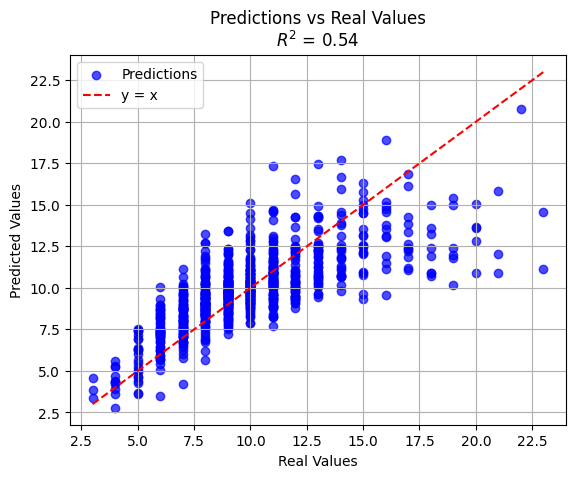

In [18]:
test_loss, predictions = evaluate_model(model, test_loader, device, criterion)
metrics = calculate_metrics(test_dataset.targets, predictions)
print(f"MAE: {metrics['MAE']:.2f}, MSE: {metrics['MSE']:.2f}, "
    f"RMSE: {metrics['RMSE']:.2f}, RMSLE: {metrics['RMSLE']:.2f}")

plot_predictions(test_dataset.targets, predictions, metrics["R2"])
plt.show()

# Plot the loss curves in tensorboard

In [19]:
%load_ext tensorboard
%tensorboard --logdir runs --port 0 --reload_interval 1

Launching TensorBoard...